# Importación de librerías

In [24]:
import matplotlib.pyplot as plt
import numpy as np
import os
import PIL
import glob
import cv2
import splitfolders
import shutil

import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras import regularizers

from sklearn import svm
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import  accuracy_score
from sklearn.metrics import precision_score, recall_score
from sklearn.model_selection import train_test_split


Montar el drive y cargar el dataset.

In [ ]:
import os
import tensorflow as tf

# root_dir = r'C:\Users\TU_RUTA_AL_DATASET\EVENODD'
# root_dir = r'C:\Users\TU_RUTA_AL_DATASET\ODD'
# root_dir = r'C:\Users\TU_RUTA_AL_DATASET\EVEN'
# root_dir = r'C:\Users\TU_RUTA_AL_DATASET\GROUP09'
root_dir = r'C:\Users\TU_RUTA_AL_DATASET\KAGGLE'


train_folder = os.path.join(root_dir, "train")
val_folder   = os.path.join(root_dir, "val")
test_folder  = os.path.join(root_dir, "test")

# Parámetros
batch_size = 32
img_height = 150
img_width = 150
dropout_rate = 0.5
epochs = 50
num_classes = 6

train_ds = tf.keras.utils.image_dataset_from_directory(
  train_folder,
  seed = 123,
  image_size = (img_height, img_width),
  batch_size = batch_size,
)

val_ds = tf.keras.utils.image_dataset_from_directory(
  val_folder,
  seed=123,
  image_size=(img_height, img_width),
  batch_size = batch_size
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_folder,
    seed = 123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

class_names = train_ds.class_names
print(class_names)

Found 6455 files belonging to 6 classes.
Found 1077 files belonging to 6 classes.
Found 1390 files belonging to 6 classes.
['cups', 'forks', 'glasses', 'knives', 'plates', 'spoons']


Creamos el training, validation y test dataset

Imprimir 9 imágenes del dataset

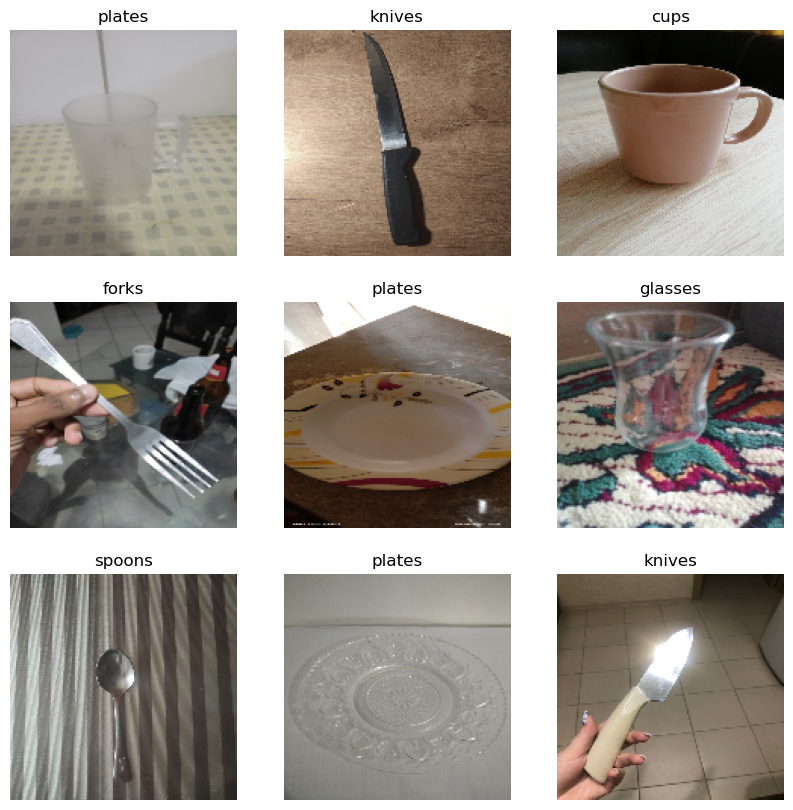

In [57]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

Arquitectura

In [63]:
import tensorflow as tf

class SparseF1Score(tf.keras.metrics.F1Score):
    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = tf.cast(y_true, tf.int32) # tipo int32
        y_true = tf.reshape(y_true, [-1]) # aplanar a 1D
        num_classes = tf.shape(y_pred)[-1] # número de clases desde y_pred
        y_true_one_hot = tf.one_hot(y_true, depth=num_classes) # convertir a One-Hot
        return super().update_state(y_true_one_hot, y_pred, sample_weight) # pasar los datos al F1Score original

Data Augmentation

In [64]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomContrast(0.2),
    layers.RandomBrightness(0.1)
])

In [ ]:
class BaselineCNN():
  def __init__(self, input_shape, num_classes):
    self.model = Sequential()
    self.model.add(data_augmentation)
    self.model.add(layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)))
    self.model.add(layers.Conv2D(32, (3,3), activation='relu', padding='same'))
    self.model.add(layers.Conv2D(32, (3,3), activation='relu', padding='same'))
    self.model.add(layers.BatchNormalization())
    self.model.add(layers.MaxPooling2D((2, 2)))

    self.model.add(layers.Conv2D(64, (3,3), activation='relu', padding='same'))
    self.model.add(layers.Conv2D(64, (3,3), activation='relu', padding='same'))
    self.model.add(layers.BatchNormalization())
    self.model.add(layers.MaxPooling2D((2, 2)))

    self.model.add(layers.Conv2D(128, (3,3), activation='relu', padding='same'))
    self.model.add(layers.Conv2D(128, (3,3), activation='relu', padding='same'))
    self.model.add(layers.BatchNormalization())
    self.model.add(layers.MaxPooling2D((2, 2)))

    self.model.add(layers.Flatten())
    self.model.add(layers.Dense(256, activation='relu'))
    self.model.add(layers.Dropout(dropout_rate))
    self.model.add(layers.Dense(num_classes, activation='softmax'))

    self.model.summary()

  def train(self):    
    self.model.compile(
      optimizer=tf.keras.optimizers.Adam(learning_rate=0.0007),
      loss=tf.keras.losses.SparseCategoricalCrossentropy(),
      metrics=['accuracy', SparseF1Score(average='weighted', name='f1_score')]
    )

  def fit_model(self):
    self.history = self.model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs
    )

  def plots(self):
    acc = self.history.history['accuracy']
    val_acc = self.history.history['val_accuracy']

    loss = self.history.history['loss']
    val_loss = self.history.history['val_loss']

    epochs_range = range(epochs)

    plt.figure(figsize=(8, 8))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')
    plt.grid(True)

  def get_predictions(self, dataset):
      y_true, y_pred, images_list = [], [], []
      for images, labels in dataset:
          preds = self.model.predict(images, verbose=0)
          y_pred.extend(np.argmax(preds, axis=1))
          y_true.extend(labels.numpy())
          images_list.extend(images.numpy())
      return np.array(y_true), np.array(y_pred), np.array(images_list)

  def plot_confusion_matrix(self, y_true, y_pred, class_names):
      cm = confusion_matrix(y_true, y_pred)
      cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

      fig, ax = plt.subplots(figsize=(8, 6))

      sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                  xticklabels=class_names, yticklabels=class_names, ax=ax)
      ax.set_title('Confusion Matrix (normalized)')
      ax.set_ylabel('True label')
      ax.set_xlabel('Predicted label')

      plt.tight_layout()
      plt.savefig('confusion_matrix.png', dpi=120)
      plt.show()


  def plot_misclassified(self, y_true, y_pred, images, class_names, n=12):
      wrong_idx = np.where(y_true != y_pred)[0]
      print(f'Total mal clasificadas: {len(wrong_idx)} / {len(y_true)}')

      show = wrong_idx[:n]
      cols = 4
      rows = int(np.ceil(len(show) / cols))

      fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
      axes = axes.flatten()

      for i, idx in enumerate(show):
          img = images[idx].astype('uint8')
          axes[i].imshow(img)
          axes[i].set_title(
              f'True: {class_names[y_true[idx]]}\nPred: {class_names[y_pred[idx]]}',
              color='red', fontsize=10)
          axes[i].axis('off')

      for j in range(i + 1, len(axes)):
          axes[j].axis('off')

      plt.suptitle(f'Imágenes mal clasificadas', fontsize=13)
      plt.tight_layout()
      plt.savefig(f'misclassified.png', dpi=120)
      plt.show()
      
  def evaluate(self):
      print("\n── Evaluación en Test ──")
      ts = test_ds
      results = self.model.evaluate(ts, verbose=1)
      for name, val in zip(self.model.metrics_names, results):
          print(f"  {name}: {val:.4f}")



Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_18 (Sequential)      │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_12 (Rescaling)        │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_42 (Conv2D)              │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_43 (Conv2D)              │ (None, 150, 150, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_36          │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_36 (MaxPooling2D) │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_44 (Conv2D)              │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_45 (Conv2D)              │ (None, 75, 75, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_37          │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_37 (MaxPooling2D) │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_46 (Conv2D)              │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_47 (Conv2D)              │ (None, 37, 37, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_38          │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_38 (MaxPooling2D) │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_12 (Flatten)            │ (None, 41472)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 256)            │    10,617,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,906,534 (41.61 MB)

 Trainable params: 10,906,086 (41.60 MB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/50
202/202 ━━━━━━━━━━━━━━━━━━━━ 112s 539ms/step - accuracy: 0.3503 - f1_score: 0.3378 - loss: 2.5162 - val_accuracy: 0.2693 - val_f1_score: 0.2446 - val_loss: 3.3285
Epoch 2/50
202/202 ━━━━━━━━━━━━━━━━━━━━ 109s 538ms/step - accuracy: 0.4857 - f1_score: 0.4619 - loss: 1.2642 - val_accuracy: 0.5469 - val_f1_score: 0.5429 - val_loss: 1.4290
Epoch 3/50
202/202 ━━━━━━━━━━━━━━━━━━━━ 107s 528ms/step - accuracy: 0.5441 - f1_score: 0.5303 - loss: 1.1152 - val_accuracy: 0.6602 - val_f1_score: 0.6766 - val_loss: 0.9282
Epoch 4/50
202/202 ━━━━━━━━━━━━━━━━━━━━ 107s 531ms/step - accuracy: 0.5994 - f1_score: 0.5911 - loss: 0.9750 - val_accuracy: 0.6156 - val_f1_score: 0.6531 - val_loss: 0.8883
Epoch 5/50
202/202 ━━━━━━━━━━━━━━━━━━━━ 108s 533ms/step - accuracy: 0.6397 - f1_score: 0.6386 - loss: 0.9009 - val_accuracy: 0.5924 - val_f1_score: 0.6275 - val_loss: 1.0045
Epoch 6/50
202/202 ━━━━━━━━━━━━━━━━━━━━ 107s 529ms/step - accuracy: 0.6582 - f1_score: 0.6580 - loss: 0.8495 - val_accuracy: 0.711

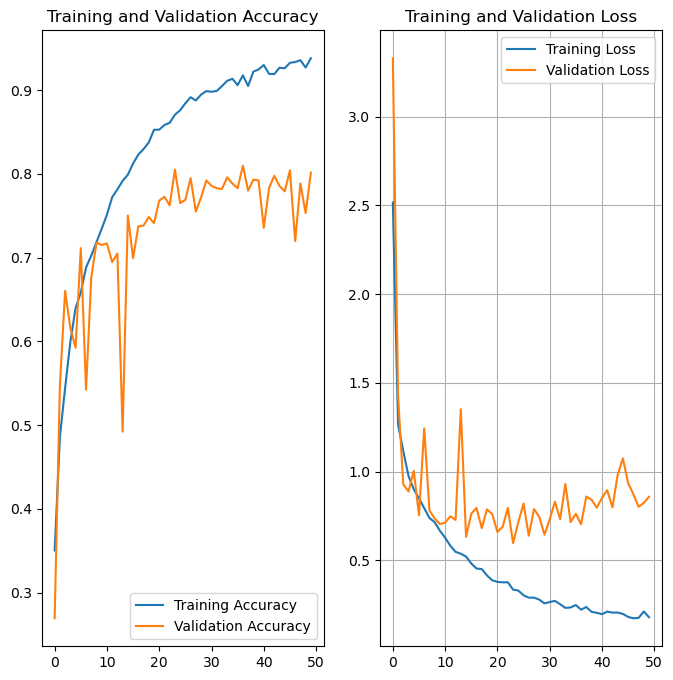

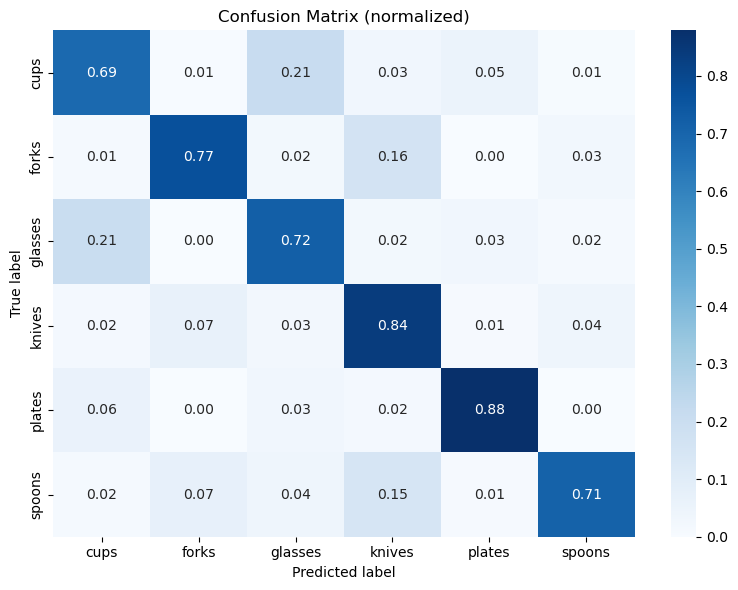

Total mal clasificadas: 321 / 1390


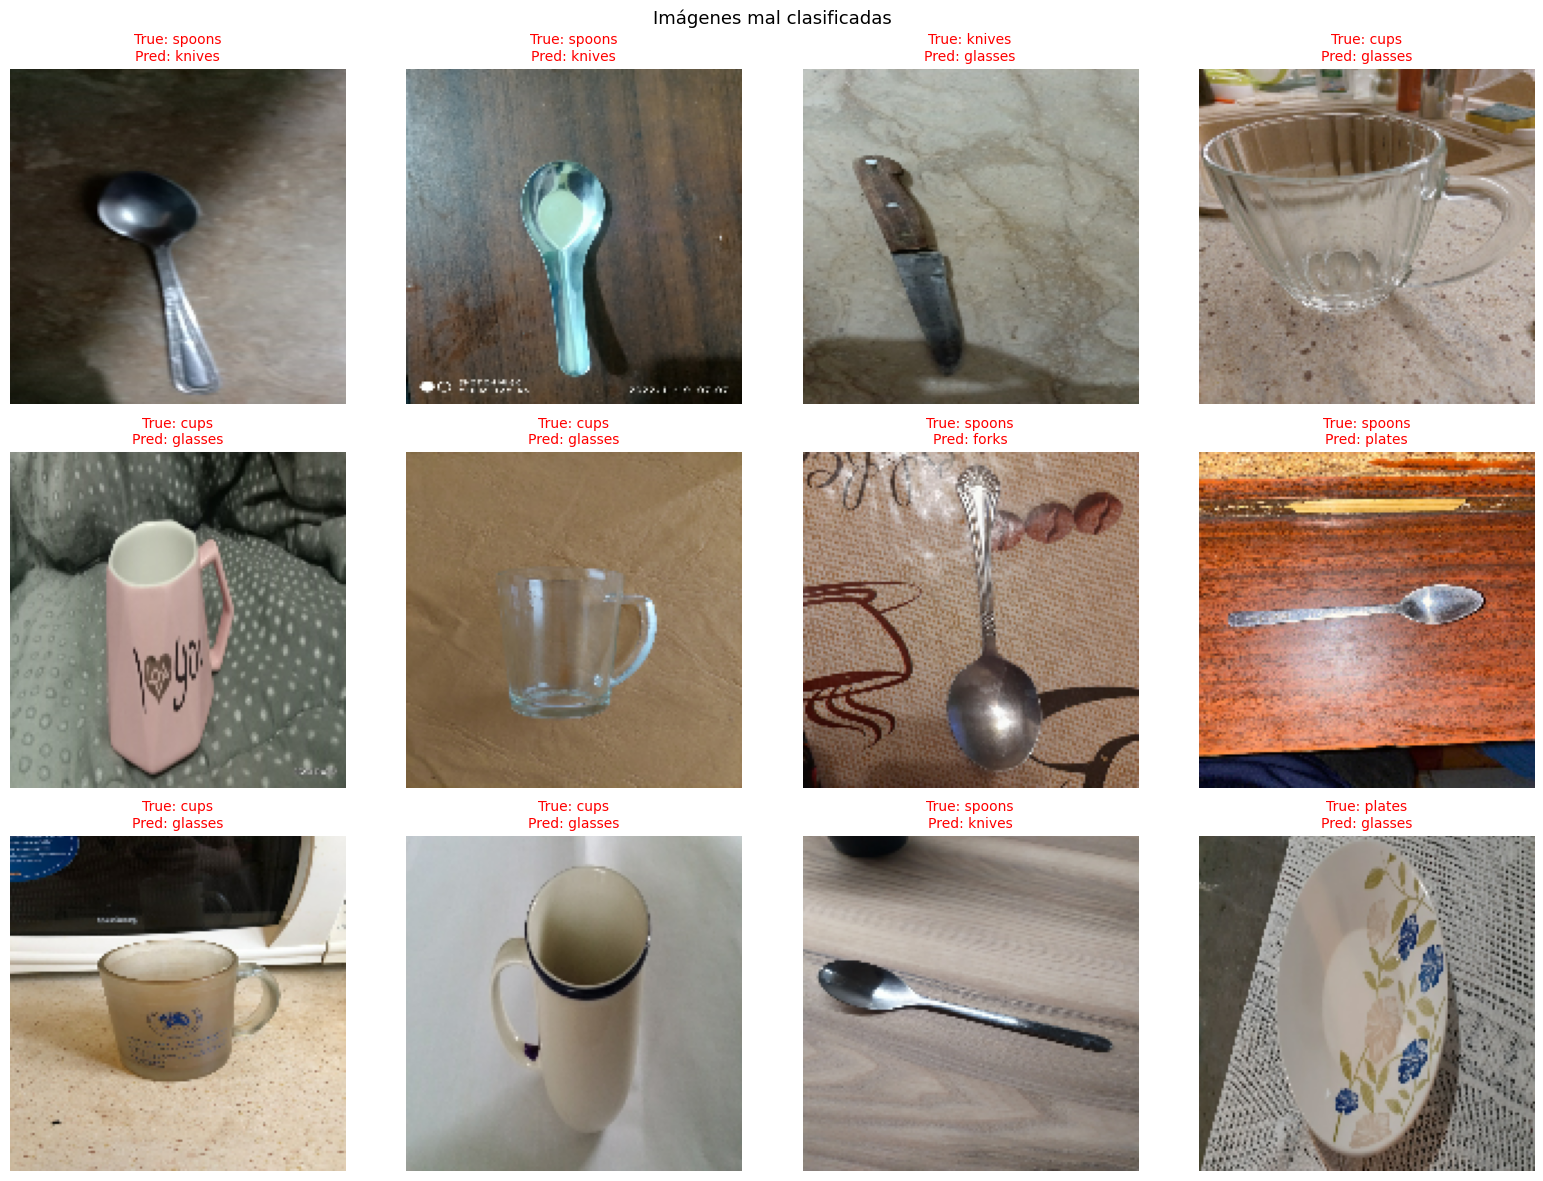

In [69]:
if __name__ == '__main__':
    model = BaselineCNN(input_shape=(224, 224, 3), num_classes=num_classes)
    model.train()
    model.fit_model()
    model.plots()
    model.evaluate()
    y_true, y_pred, images_arr = model.get_predictions(test_ds)
    model.plot_confusion_matrix(y_true, y_pred, class_names)
    model.plot_misclassified(y_true, y_pred, images_arr, class_names, n=12)